In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load tiepoint dataset
df = pd.read_csv('time_analysis_2_hour/tiepoints.csv')
df.columns = [c.strip() for c in df.columns]

# Extract host timestamps (ns) and FPGA counter values (us)
host_ns = df['# host_unix_ns'].values
fpga_us = df['fpga_counter_us'].values

# Convert to relative time in seconds from start
host_sec = (host_ns - host_ns[0]) / 1e9
fpga_sec = (fpga_us - fpga_us[0]) / 1e6

# Perform linear regression fit
slope, intercept = np.polyfit(fpga_sec, host_sec, 1)
pred_host_sec = slope * fpga_sec + intercept

# Residual errors in milliseconds
residuals_ms = (host_sec - pred_host_sec) * 1000
mean_res = np.mean(residuals_ms)
std_res = np.std(residuals_ms)




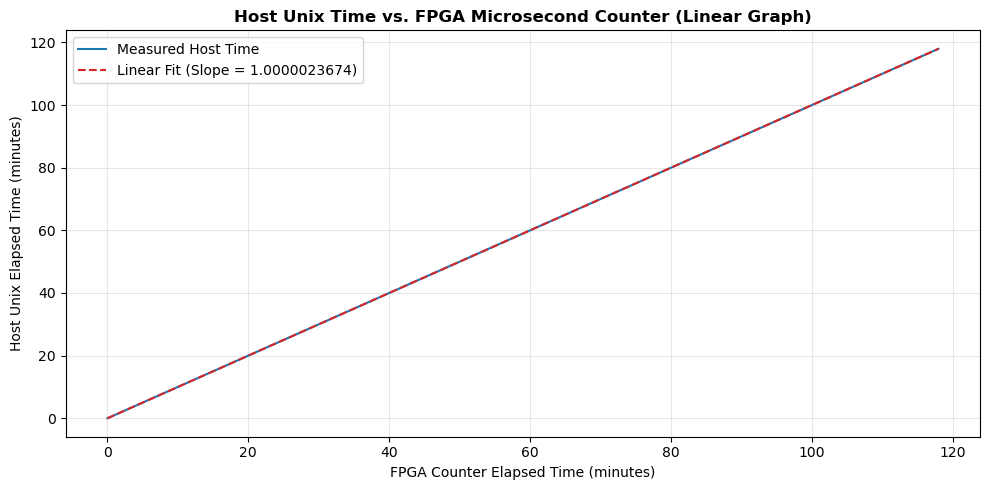

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(fpga_sec / 60, host_sec / 60, color='#1f77b4', linewidth=1.5, label='Measured Host Time')
plt.plot(fpga_sec / 60, pred_host_sec / 60, color='#d62728', linestyle='--', label=f'Linear Fit (Slope = {slope:.10f})')
plt.title('Host Unix Time vs. FPGA Microsecond Counter (Linear Graph)', fontsize=12, fontweight='bold')
plt.xlabel('FPGA Counter Elapsed Time (minutes)')
plt.ylabel('Host Unix Elapsed Time (minutes)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


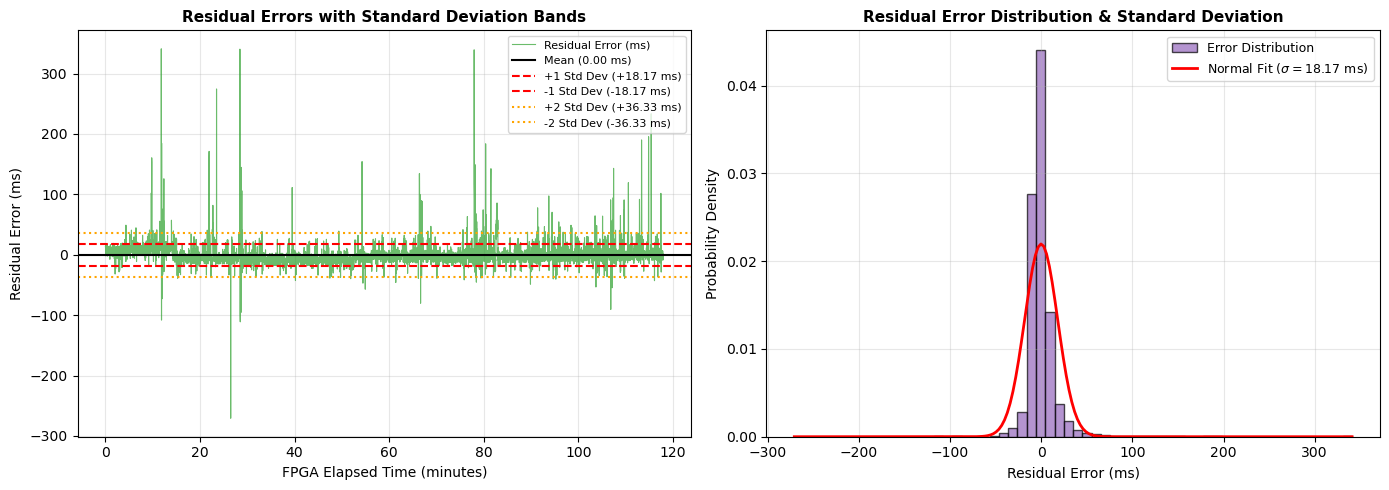

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Residual Jitter with Standard Deviation Bands
ax1.plot(fpga_sec / 60, residuals_ms, color='#2ca02c', alpha=0.7, linewidth=0.8, label='Residual Error (ms)')
ax1.axhline(mean_res, color='black', linestyle='-', label=f'Mean ({mean_res:.2f} ms)')
ax1.axhline(mean_res + std_res, color='red', linestyle='--', label=f'+1 Std Dev (+{std_res:.2f} ms)')
ax1.axhline(mean_res - std_res, color='red', linestyle='--', label=f'-1 Std Dev (-{std_res:.2f} ms)')
ax1.axhline(mean_res + 2*std_res, color='orange', linestyle=':', label=f'+2 Std Dev (+{2*std_res:.2f} ms)')
ax1.axhline(mean_res - 2*std_res, color='orange', linestyle=':', label=f'-2 Std Dev (-{2*std_res:.2f} ms)')
ax1.set_title('Residual Errors with Standard Deviation Bands', fontsize=11, fontweight='bold')
ax1.set_xlabel('FPGA Elapsed Time (minutes)')
ax1.set_ylabel('Residual Error (ms)')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Residual Distribution Histogram & Gaussian Curve
ax2.hist(residuals_ms, bins=60, color='#9467bd', edgecolor='black', alpha=0.7, density=True, label='Error Distribution')
x_axis = np.linspace(np.min(residuals_ms), np.max(residuals_ms), 200)
gaussian = (1 / (std_res * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_axis - mean_res) / std_res) ** 2)
ax2.semilogy(x_axis, gaussian, color='red', linewidth=2, label=f'Normal Fit ($\sigma = {std_res:.2f}$ ms)')
ax2.set_title('Residual Error Distribution & Standard Deviation', fontsize=11, fontweight='bold')
ax2.set_xlabel('Residual Error (ms)')
ax2.set_ylabel('Probability Density')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
